In [1]:
import pandas as pd

df = pd.read_csv("heart.csv")



In [2]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
%pip install pandas matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install numpy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("heart.csv")

In [8]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [9]:
from sklearn.model_selection import train_test_split
x,y = df.drop("target" , axis=1) , df ["target"]
x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size=0.4, random_state=9)

### Scale-Insenstive

In [10]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(random_state=9)
forest.fit(x_train, y_train)

RandomForestClassifier(random_state=9)

In [11]:
from sklearn.naive_bayes import GaussianNB
nb_clf = GaussianNB()
nb_clf.fit(x_train, y_train)

GaussianNB()

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier()
gb_clf.fit(x_train, y_train)

GradientBoostingClassifier()

### Scale-Sensitive

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_scaled , y_train)

KNeighborsClassifier()

In [15]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(x_train_scaled , y_train)

LogisticRegression()

In [16]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train_scaled , y_train)

SVC()

In [17]:
forest.score(x_test, y_test)

0.9853658536585366

In [18]:
nb_clf.score(x_test, y_test)

0.8463414634146341

In [19]:
gb_clf.score(x_test,y_test)

0.9707317073170731

In [20]:
knn.score(x_test_scaled, y_test)

0.8536585365853658

In [21]:
log.score(x_test_scaled, y_test)

0.8731707317073171

In [22]:
svc.score(x_test_scaled, y_test)

0.9341463414634147

In [23]:
from sklearn.metrics import recall_score

y_preds = forest.predict(x_test)
print("forest:", recall_score(y_test , y_preds))

y_preds = nb_clf.predict(x_test)
print("NB:" , recall_score(y_test , y_preds))

y_preds = gb_clf.predict(x_test)
print("GB:" , recall_score(y_test , y_preds))

y_preds = knn.predict(x_test_scaled)
print("KNN:" , recall_score(y_test , y_preds))


y_preds = log.predict(x_test_scaled)
print("LOG:" , recall_score(y_test , y_preds))


y_preds = svc.predict(x_test_scaled)
print("SVC:" , recall_score(y_test , y_preds))

forest: 0.9859154929577465
NB: 0.9014084507042254
GB: 0.9859154929577465
KNN: 0.8732394366197183
LOG: 0.92018779342723
SVC: 0.9530516431924883


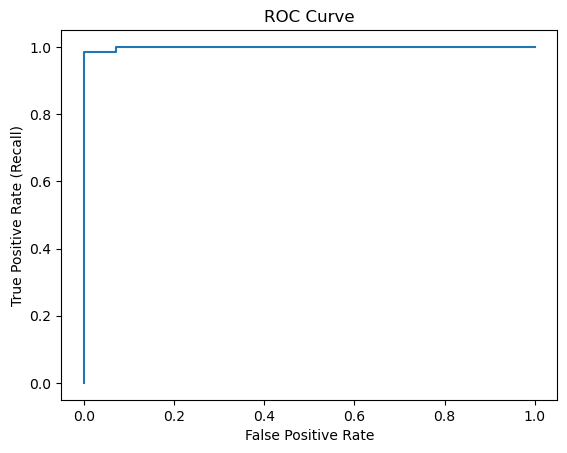

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = forest.predict_proba(x_test)[:, 1]

fpr , tpr , thresholds = roc_curve (y_test , y_probs)
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.show()

In [25]:
roc_auc_score(y_test, y_probs)

0.9989990705655251

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


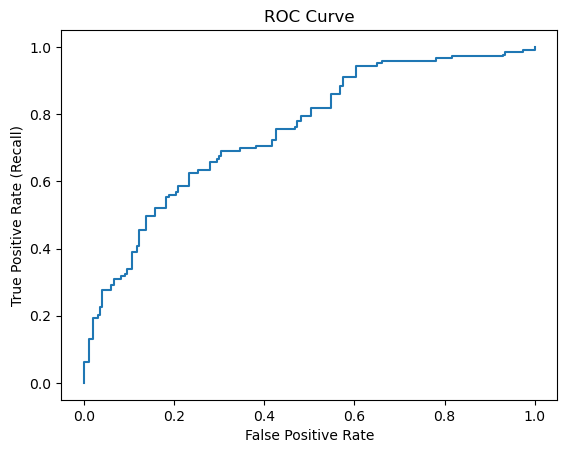

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = log.predict_proba(x_test)[:, 1]

fpr , tpr , thresholds = roc_curve (y_test , y_probs)
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.savefig('ROC_Curve', dpi=300, bbox_inches='tight')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


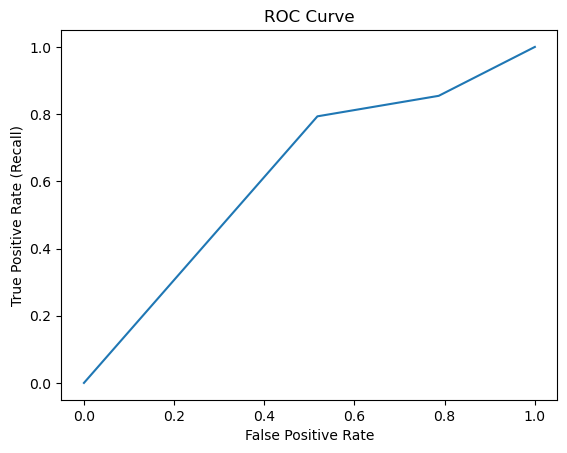

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = knn.predict_proba(x_test)[:, 1]

fpr , tpr , thresholds = roc_curve (y_test , y_probs)
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.show()

### Hyperparameter Tuning


In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

forest = RandomForestClassifier(
    n_jobs=-1,
    random_state=9
)

grid_search = GridSearchCV(
    forest,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)


Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=9),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             verbose=2)

In [29]:
best_forest = grid_search.best_estimator_

In [30]:
best_forest

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=9)

### Feature Importances

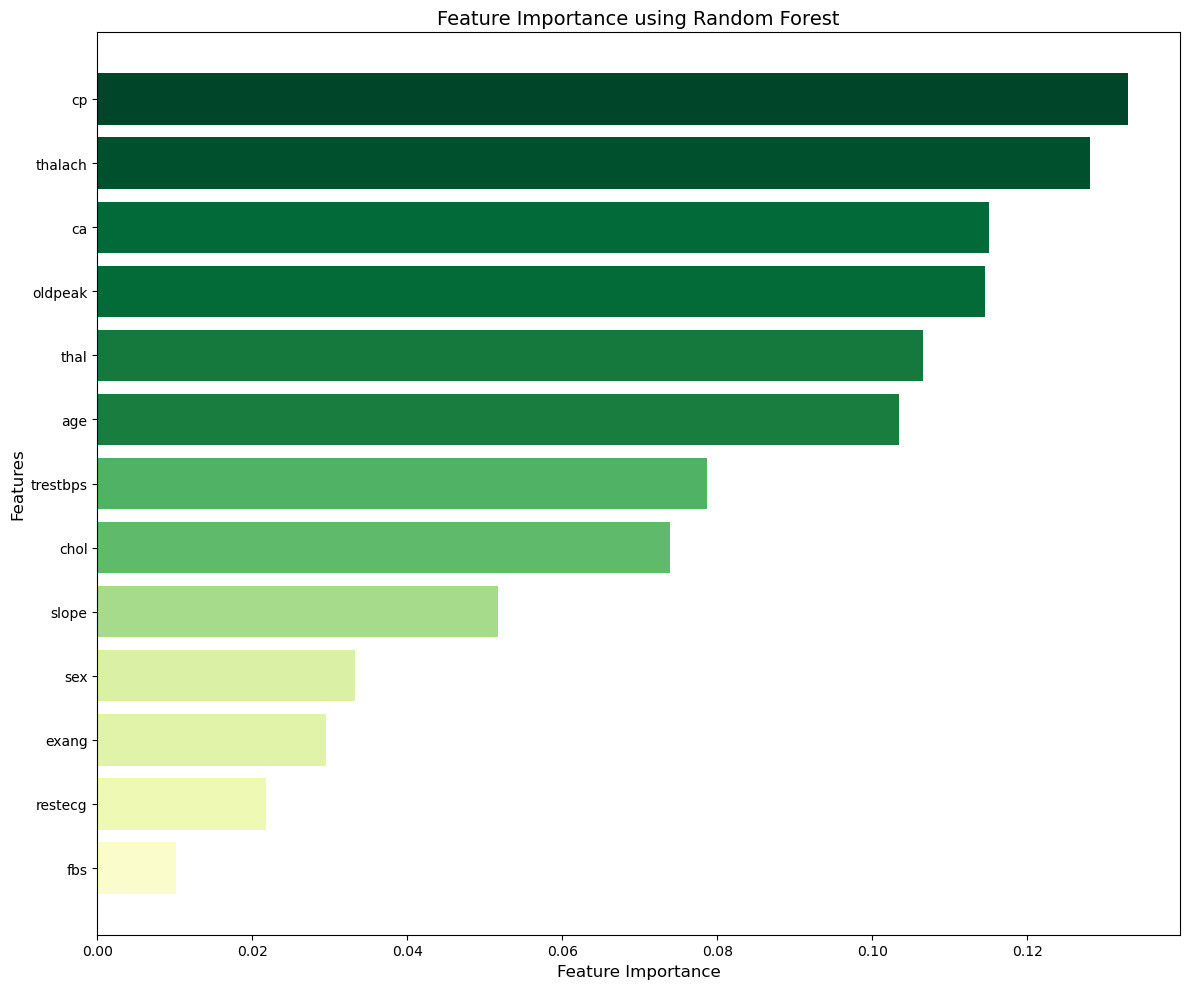

In [38]:
plt.figure(figsize=(12, 10))
plt.barh(sorted_features, sorted_importances, color=colors)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance using Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

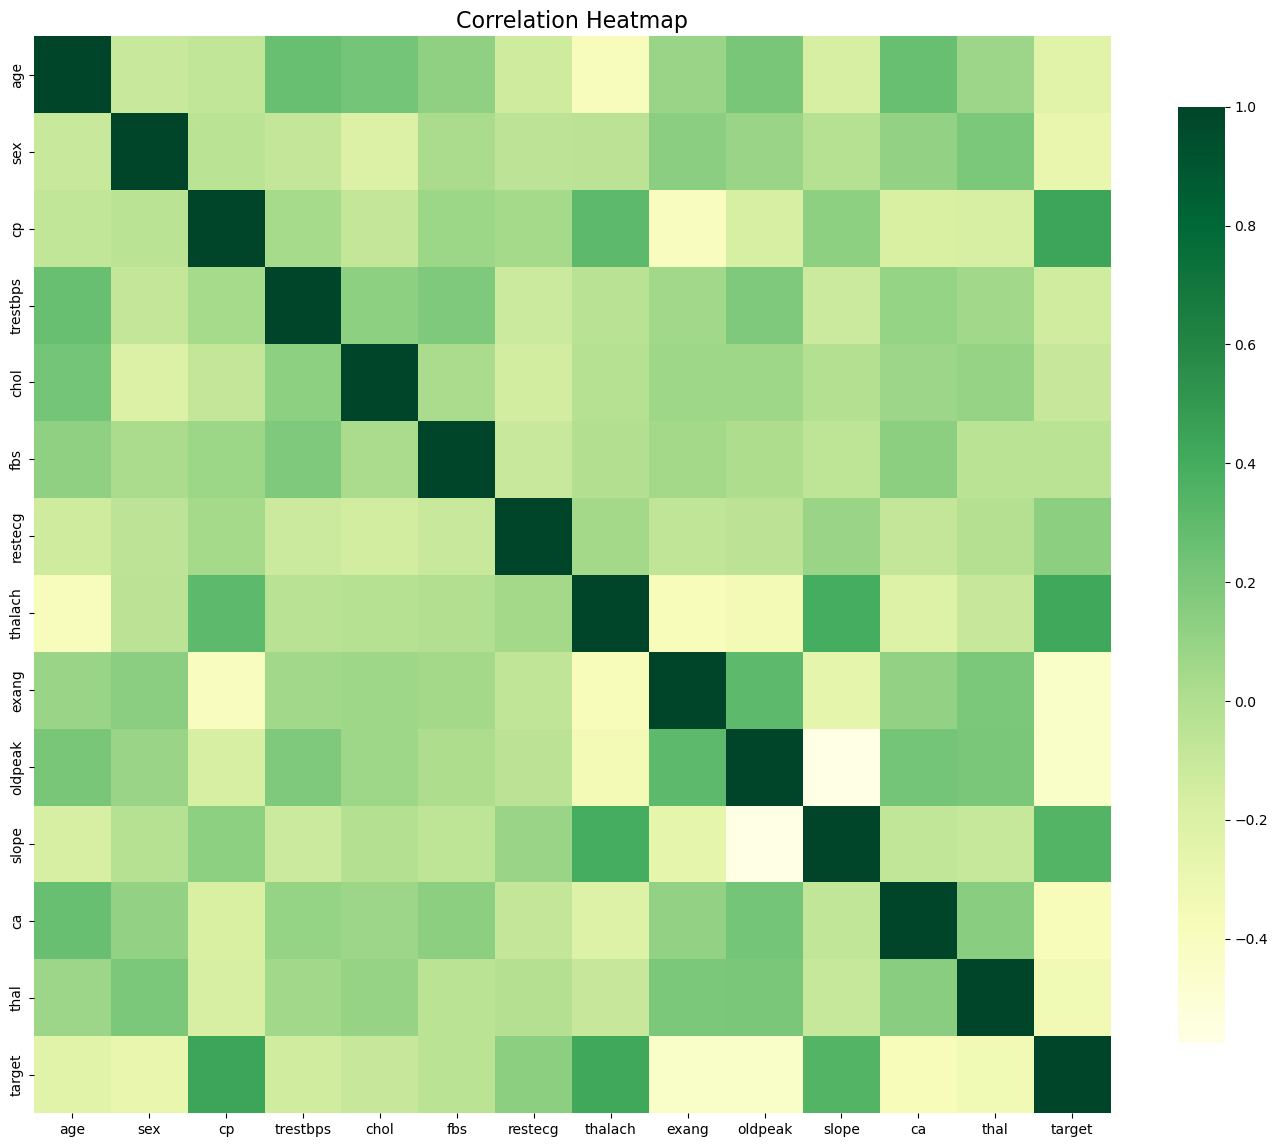

In [37]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    df.corr(),
    cmap='YlGn',
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



In [39]:
import os
os.getcwd()



'C:\\Users\\Hajra Syed\\TASK 4'